# Document Filtering Phase 2: Text + FairFace + Object Labels  
### Multimodal label-token features → Naïve Bayes → Fisher’s Method

This notebook uses the **merged dataset** for binary offensive-language classification:

- `0` = **non_offensive**
- `1` = **offensive**

**Phase 2 change:** each example is represented by a combined tokenizer string:

```text
original text + FairFace labels from human_results.csv + object labels from object_detections.csv
```

The joined feature field is called `model_text`. The classifiers still operate as document filters, but the “document” now contains text tokens plus image-derived label tokens such as `fairface_race_white`, `fairface_gender_male`, `fairface_age_30_39`, and `object_person`.


In [1]:
# %matplotlib inline
# Core scientific stack
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train/test split + baselines
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay
)

# Fisher's method needs the chi-square distribution
from scipy.stats import chi2

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Label names used throughout the notebook
NEGATIVE_LABEL = "non_offensive"
POSITIVE_LABEL = "offensive"
LABEL_MAP = {0: NEGATIVE_LABEL, 1: POSITIVE_LABEL}
CLASS_ORDER = [NEGATIVE_LABEL, POSITIVE_LABEL]


## 1) Problem definition (offensive-language filter)

**Input:** a document/text $d \in \mathcal{D}$.  
**Output:** a class label $c \in \mathcal{C}=\{\mathrm{offensive},\mathrm{non\_offensive}\}$.

The merged dataset stores labels as numbers:

- `0` = **non_offensive**
- `1` = **offensive**

Given labeled training data $\mathcal{S}=\{(d_i,c_i)\}_{i=1}^{N},$

we learn a classifier $f:\mathcal{D}	o\mathcal{C}$, equivalently a model of $p(c\mid d)$,

and predict for an unseen document $d$ via
$
\hat{c}(d)=rg\max_{c\in\mathcal{C}} p(c\mid d).
$

In this lecture we focus on:
- **Feature engineering:** $x=\phi(d)\in\mathbb{R}^{V}$, e.g. Bag-of-Words / TF–IDF
- **Naïve Bayes**
- **Fisher’s method**


In [2]:
# Load the merged dataset + phase 2 metadata.
# Main label convention:
#   0 = non_offensive
#   1 = offensive
# Phase 2 feature input:
#   text + FairFace labels from human_results.csv + object labels from object_detections.csv

from pathlib import Path
from collections import Counter

DATA_PATH = Path("merged_dataset.csv")
HUMAN_PATH = Path("human_results.csv")
OBJECT_PATH = Path("object_detections.csv")

# Fallbacks are useful when running the notebook from this sandbox location.
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/merged_dataset.csv")
if not HUMAN_PATH.exists():
    HUMAN_PATH = Path("/mnt/data/human_results.csv")
if not OBJECT_PATH.exists():
    OBJECT_PATH = Path("/mnt/data/object_detections.csv")

raw_df = pd.read_csv(DATA_PATH)
human_df = pd.read_csv(HUMAN_PATH)
object_df = pd.read_csv(OBJECT_PATH)

def normalise_filename(value):
    """Make filenames joinable, e.g. 01235.png.png -> 01235.png."""
    value = str(value).strip()
    while value.endswith(".png.png"):
        value = value[:-4]
    return value

def tokenise_label(prefix, value):
    """Convert a metadata label into a safe tokenizer token."""
    if pd.isna(value):
        return None
    value = str(value).strip().lower()
    value = re.sub(r"[^a-z0-9]+", "_", value).strip("_")
    return f"{prefix}_{value}" if value else None

# -----------------------------
# Aggregate FairFace labels per image
# -----------------------------
human_df["filename_norm"] = human_df["filename"].map(normalise_filename)

fairface_rows = []
for filename, group in human_df.groupby("filename_norm"):
    tokens = []
    for _, row in group.iterrows():
        for col in ["race", "gender", "age"]:
            tok = tokenise_label(f"fairface_{col}", row.get(col))
            if tok:
                tokens.append(tok)
    counts = Counter(tokens)
    fairface_rows.append({
        "filename_norm": filename,
        "fairface_text": " ".join(tokens),
        "fairface_unique": " ".join(sorted(counts)),
        "num_faces": int(len(group)),
    })
fairface_features = pd.DataFrame(fairface_rows)

# -----------------------------
# Aggregate object labels per image
# -----------------------------
object_df["filename_norm"] = object_df["filename"].map(normalise_filename)

object_rows = []
for filename, group in object_df.groupby("filename_norm"):
    tokens = []
    for label in group["object_label"].dropna():
        tok = tokenise_label("object", label)
        if tok:
            tokens.append(tok)
    counts = Counter(tokens)
    object_rows.append({
        "filename_norm": filename,
        "object_text": " ".join(tokens),
        "object_unique": " ".join(sorted(counts)),
        "num_objects": int(len(group)),
    })
object_features = pd.DataFrame(object_rows)

# -----------------------------
# Join everything into one modelling table
# -----------------------------
df = raw_df.copy()
df["filename_norm"] = df["filename"].map(normalise_filename)
df["text"] = df["text"].fillna("").astype(str)
df["label"] = pd.to_numeric(df["label"], errors="coerce").map(LABEL_MAP)

df = df.merge(fairface_features, on="filename_norm", how="left")
df = df.merge(object_features, on="filename_norm", how="left")

for col in ["fairface_text", "fairface_unique", "object_text", "object_unique"]:
    df[col] = df[col].fillna("")
for col in ["num_faces", "num_objects"]:
    df[col] = df[col].fillna(0).astype(int)

# The tokenizer/vectorizer input for phase 2.
df["model_text"] = (
    df["text"].fillna("").astype(str) + " " +
    df["fairface_text"] + " " +
    df["object_text"]
).str.strip()

df = df.dropna(subset=["label", "model_text"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Main columns:", ["filename", "label", "text", "fairface_text", "object_text", "model_text", "split"])
print("Images with FairFace labels:", int((df["fairface_text"] != "").sum()))
print("Images with object labels:", int((df["object_text"] != "").sum()))
df[["filename", "label", "text", "fairface_unique", "object_unique", "model_text"]].head()


Dataset shape: (9000, 13)
Main columns: ['filename', 'label', 'text', 'fairface_text', 'object_text', 'model_text', 'split']
Images with FairFace labels: 7434
Images with object labels: 8378


,filename,label,text,fairface_unique,object_unique,model_text
0,42953.png,non_offensive,its their character not their color that matters,fairface_age_30_39 fairface_gender_male fairfa...,object_person,its their character not their color that matte...
1,23058.png,non_offensive,don't be afraid to love again everyone is not ...,fairface_age_20_29 fairface_age_30_39 fairface...,object_person object_tie,don't be afraid to love again everyone is not ...
2,13894.png,non_offensive,putting bows on your pet,,object_cat,putting bows on your pet object_cat object_cat
3,37408.png,non_offensive,i love everything and everybody! except for sq...,,object_dog,i love everything and everybody! except for sq...
4,82403.png,non_offensive,"everybody loves chocolate chip cookies, even h...",fairface_age_20_29 fairface_gender_male fairfa...,object_person object_tie,"everybody loves chocolate chip cookies, even h..."


### Quick sanity check: label balance

In [3]:
df['label'].value_counts()

label
non_offensive    5700
offensive        3300
Name: count, dtype: int64

### Phase 2 feature coverage

This confirms how many merged-dataset rows received FairFace labels, object labels, or both.

In [4]:
coverage = pd.Series({
    "rows": len(df),
    "with_fairface_labels": int((df["fairface_text"] != "").sum()),
    "with_object_labels": int((df["object_text"] != "").sum()),
    "with_both": int(((df["fairface_text"] != "") & (df["object_text"] != "")).sum()),
    "without_extra_labels": int(((df["fairface_text"] == "") & (df["object_text"] == "")).sum()),
})
coverage


rows                    9000
with_fairface_labels    7434
with_object_labels      8378
with_both               7360
without_extra_labels     548
dtype: int64

## 2) Train / test split

We keep the dataset small, so we use a simple split (stratified by label).


In [5]:
# Use the existing split column if it is available; otherwise create a stratified split.
# IMPORTANT: Phase 2 trains on model_text, which is text + FairFace labels + object labels.
FEATURE_COLUMN = "model_text"

if "split" in df.columns and df["split"].notna().any():
    split_values = df["split"].astype(str).str.lower()
    train_mask = split_values.eq("train")
    test_mask = split_values.isin(["test", "valid", "validation", "val", "dev"])

    # If the split column is incomplete, fall back to a stratified random split.
    if train_mask.any() and test_mask.any():
        train_split_df = df.loc[train_mask].copy()
        test_split_df = df.loc[test_mask].copy()

        X_train = train_split_df[FEATURE_COLUMN]
        y_train = train_split_df["label"]
        X_test = test_split_df[FEATURE_COLUMN]
        y_test = test_split_df["label"]
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            df[FEATURE_COLUMN], df["label"],
            test_size=0.40,
            random_state=RANDOM_STATE,
            stratify=df["label"]
        )
else:
    X_train, X_test, y_train, y_test = train_test_split(
        df[FEATURE_COLUMN], df["label"],
        test_size=0.40,
        random_state=RANDOM_STATE,
        stratify=df["label"]
    )

print(f"Feature column: {FEATURE_COLUMN}")
print(f"train={len(X_train)}, test={len(X_test)}")
print("Train labels:")
print(y_train.value_counts())
print("\nTest labels:")
print(y_test.value_counts())


Feature column: model_text
train=8500, test=500
Train labels:
label
non_offensive    5450
offensive        3050
Name: count, dtype: int64

Test labels:
label
offensive        250
non_offensive    250
Name: count, dtype: int64


## 3) Feature engineering

### 3.1 Tokenizer vector: text + FairFace labels + object labels

**Phase 2 idea:** represent each example as one combined string:

```text
original text + fairface_* tokens + object_* tokens
```

The tokenizer keeps normal words and metadata tokens such as `fairface_race_white`, `fairface_gender_male`, `fairface_age_30_39`, and `object_person`.


In [12]:
def tokenize(text: str):
    # Phase 2 tokenizer:
    # - lowercase
    # - keep normal words
    # - keep metadata tokens with numbers/underscores, e.g. fairface_age_30_39, object_cell_phone
    return re.findall(r"[a-z0-9_]+", str(text).lower())

# Example: inspect tokens from the phase 2 feature field
example = df["model_text"].iloc[0]
print("Example model_text:", example)
print("Tokens:", tokenize(example))


Example model_text: its their character not their color that matters fairface_race_white fairface_gender_male fairface_age_30_39 fairface_race_white fairface_gender_male fairface_age_30_39 object_person object_person
Tokens: ['its', 'their', 'character', 'not', 'their', 'color', 'that', 'matters', 'fairface_race_white', 'fairface_gender_male', 'fairface_age_30_39', 'fairface_race_white', 'fairface_gender_male', 'fairface_age_30_39', 'object_person', 'object_person']


### 3.2 Bag of Words / tokenizer vector (`CountVectorizer`)

We use `binary=True` so each text, FairFace, or object token is **1 if present**, **0 if absent**.


In [14]:
bow_vec = CountVectorizer(
    tokenizer=tokenize,
    lowercase=False,   # we already lowercase in tokenize()
    binary=True
)

X_train_bow = bow_vec.fit_transform(X_train)
X_test_bow  = bow_vec.transform(X_test)

print("Vocabulary size:", len(bow_vec.vocabulary_))
print("Train matrix:", X_train_bow.shape, "Test matrix:", X_test_bow.shape)


E:\anaconda\Lib\site-packages\sklearn\feature_extraction\text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Vocabulary size: 8984
Train matrix: (8500, 8984) Test matrix: (500, 8984)


### 3.3 TF–IDF (from Search & Ranking)

TF–IDF down-weights very common words and highlights distinctive ones.

A standard definition:

- **Term frequency:** $\mathrm{tf}(t,d)$ (e.g., raw count or log-scaled count)
- **Inverse document frequency:**
  $
  \mathrm{idf}(t)=\log\frac{N}{\mathrm{df}(t)},
  $
  where $\mathrm{df}(t)$ is the number of documents containing term $t$ and $N$ is the total number of documents.
- **TF–IDF weight:**
  $
  \mathrm{tfidf}(t,d)=\mathrm{tf}(t,d)\cdot \mathrm{idf}(t).
  $
  


In [16]:
tfidf_vec = TfidfVectorizer(
    tokenizer=tokenize,
    lowercase=False,
)

X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf  = tfidf_vec.transform(X_test)

print("TF–IDF vocab size:", len(tfidf_vec.vocabulary_))


E:\anaconda\Lib\site-packages\sklearn\feature_extraction\text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


TF–IDF vocab size: 8984


In [17]:
def top_tfidf_terms(text, vectorizer=tfidf_vec, top_k=10):
    v = vectorizer.transform([text])
    row = v.toarray().ravel()
    idx = np.argsort(row)[::-1][:top_k]
    terms = np.array(vectorizer.get_feature_names_out())[idx]
    weights = row[idx]
    out = pd.DataFrame({"term": terms, "tfidf": weights})
    return out[out["tfidf"] > 0]

demo_text = X_test.iloc[0]
print("Demo message:", demo_text)
top_tfidf_terms(demo_text, top_k=12)


Demo message: white people is this a shooting range fairface_race_east_asian fairface_gender_female fairface_age_20_29 fairface_race_white fairface_gender_female fairface_age_20_29 fairface_race_white fairface_gender_male fairface_age_30_39 fairface_race_east_asian fairface_gender_male fairface_age_20_29 fairface_race_white fairface_gender_female fairface_age_20_29 fairface_race_white fairface_gender_male fairface_age_20_29 object_person object_person object_person object_person object_person


,term,tfidf
0,range,0.417639
1,fairface_age_20_29,0.387907
2,shooting,0.353886
3,object_person,0.316548
4,fairface_race_white,0.286214
5,fairface_gender_male,0.259929
6,fairface_race_east_asian,0.250199
7,fairface_gender_female,0.248684
8,white,0.221277
9,people,0.201225


## 4) Approach A — Naïve Bayes (from scratch)

### 4.1 The core probabilities

For a feature (word) $f$ and class $c$:

- $n_c$: number of documents in class $c$
- $n_{fc}$: number of documents in class $c$ that contain feature $f$

The conditional feature probability is
$$
p(f\mid c)=\frac{n_{fc}}{n_c}.
$$

For a document $d$ represented by the set of its features, the naïve conditional independence assumption gives
$$
p(d\mid c)=\prod_{f\in d} p(f\mid c).
$$

By Bayes’ rule,
$$
p(c\mid d)\propto p(c)\,p(d\mid c).
$$

In practice we use logs to avoid underflow:
$$
\log p(c\mid d)=\log p(c)+\sum_{f\in d}\log p(f\mid c)+\mathrm{const}.
$$


### 4.2 Smoothing by an assumed probability (as in the slides)

When training data is small, a word may never appear in offensive, so $p(f\mid \mathrm{offensive})=0$, which would drive the product $p(d\mid c)$ to zero.

We therefore use a weighted (smoothed) estimate:
$$
p_w(f\mid c)=\frac{w\,a+\mathrm{count}(f)\,p_{\mathrm{raw}}(f\mid c)}{\mathrm{count}(f)+w}.
$$

- $a$: assumed probability (e.g., $0.5$)
- $w$: weight (how strongly we trust the assumption)
- $\mathrm{count}(f)$: how often feature $f$ was observed overall
- $p_{\mathrm{raw}}(f\mid c)$: empirical estimate from data (e.g., $n_{fc}/n_c$)


In [20]:
class NaiveBayesScratch:
    '''
    Naïve Bayes classifier closely following the slide derivation:
      - features are word PRESENCE (set of tokens)
      - p(f|c) = n_fc / n_c  where n_fc counts documents containing f
      - smoothing via assumed probability (weighted estimate)
    '''
    def __init__(self, assumed: float = 0.5, weight: float = 1.0):
        self.assumed = assumed
        self.weight = weight
        self.fc = {}   # feature -> {class -> count}
        self.cc = {}   # class -> doc count

    @staticmethod
    def features(text: str):
        return set(tokenize(text))

    def incf(self, f, c):
        self.fc.setdefault(f, {})
        self.fc[f][c] = self.fc[f].get(c, 0) + 1

    def incc(self, c):
        self.cc[c] = self.cc.get(c, 0) + 1

    def train(self, texts, labels):
        for text, c in zip(texts, labels):
            feats = self.features(text)
            for f in feats:
                self.incf(f, c)
            self.incc(c)

    def categories(self):
        return list(self.cc.keys())

    def fcount(self, f, c):
        return self.fc.get(f, {}).get(c, 0)

    def catcount(self, c):
        return self.cc.get(c, 0)

    def totalcount(self):
        return sum(self.cc.values())

    def fprob_raw(self, f, c):
        # p(f|c) = n_fc / n_c
        if self.catcount(c) == 0:
            return 0.0
        return self.fcount(f, c) / self.catcount(c)

    def weighted_fprob(self, f, c):
        # Slide formula: p_w(f|c) = (w*a + count*p_raw) / (count+w)
        count = sum(self.fc.get(f, {}).values())  # total across categories
        raw = self.fprob_raw(f, c)
        return (self.weight * self.assumed + count * raw) / (count + self.weight)

    def log_doc_likelihood(self, text, c):
        # log p(d|c) = sum_{f in d} log p_w(f|c)
        feats = self.features(text)
        s = 0.0
        for f in feats:
            p = self.weighted_fprob(f, c)
            s += math.log(p)
        return s

    def log_posterior_unnorm(self, text, c):
        # log p(c|d) ∝ log p(c) + log p(d|c)
        prior = self.catcount(c) / self.totalcount()
        return math.log(prior) + self.log_doc_likelihood(text, c)

    def predict_proba(self, text):
        cats = self.categories()
        logs = np.array([self.log_posterior_unnorm(text, c) for c in cats], dtype=float)
        m = logs.max()
        probs = np.exp(logs - m)
        probs = probs / probs.sum()
        return dict(zip(cats, probs))

    def predict(self, text):
        probs = self.predict_proba(text)
        return max(probs, key=probs.get)

# Train the scratch NB model
nb_scratch = NaiveBayesScratch(assumed=0.5, weight=1.0)
nb_scratch.train(X_train.tolist(), y_train.tolist())

# Peek at probabilities of a few tokens (raw vs smoothed)
tokens_to_check = ["love", "hate", "people", "fairface_gender_male", "fairface_race_white", "object_person"]
rows = []
for tok in tokens_to_check:
    for c in CLASS_ORDER:
        rows.append({
            "token": tok,
            "class": c,
            "p_raw(f|c)": nb_scratch.fprob_raw(tok, c),
            "p_weighted(f|c)": nb_scratch.weighted_fprob(tok, c),
            "n_fc": nb_scratch.fcount(tok, c),
            "n_c": nb_scratch.catcount(c),
        })
pd.DataFrame(rows)


,token,class,p_raw(f|c),p_weighted(f|c),n_fc,n_c
0,love,non_offensive,0.015963,0.019836,87,5450
1,love,offensive,0.012131,0.016034,37,3050
2,hate,non_offensive,0.008624,0.013394,47,5450
3,hate,offensive,0.018033,0.022712,55,3050
4,people,non_offensive,0.048991,0.049898,267,5450
5,people,offensive,0.075082,0.075937,229,3050
6,fairface_gender_male,non_offensive,0.510459,0.510456,2782,5450
7,fairface_gender_male,offensive,0.538033,0.538024,1641,3050
8,fairface_race_white,non_offensive,0.679450,0.679419,3703,5450
9,fairface_race_white,offensive,0.720000,0.719963,2196,3050


### 4.3 Visualise the effect of smoothing for one feature

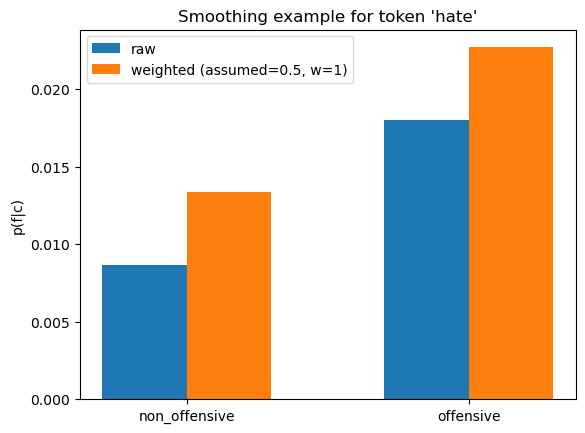

In [22]:
tok = "hate"
classes = CLASS_ORDER
raw = [nb_scratch.fprob_raw(tok, c) for c in classes]
smoothed = [nb_scratch.weighted_fprob(tok, c) for c in classes]

plt.figure()
plt.bar(np.arange(len(classes)) - 0.15, raw, width=0.3, label="raw")
plt.bar(np.arange(len(classes)) + 0.15, smoothed, width=0.3, label="weighted (assumed=0.5, w=1)")
plt.xticks(np.arange(len(classes)), classes)
plt.ylabel("p(f|c)")
plt.title(f"Smoothing example for token '{tok}'")
plt.legend()
plt.show()


### 4.4 Evaluate Naïve Bayes (scratch)

In [24]:
def eval_classifier(predict_fn, X, y, positive_label=POSITIVE_LABEL):
    y_pred = [predict_fn(x) for x in X]
    acc = accuracy_score(y, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(
        y, y_pred, pos_label=positive_label, average="binary", zero_division=0
    )
    return {
        "accuracy": float(acc),
        f"precision({positive_label})": float(pr),
        f"recall({positive_label})": float(rc),
        f"f1({positive_label})": float(f1)
    }, y_pred

nb_metrics, nb_pred = eval_classifier(nb_scratch.predict, X_test.tolist(), y_test.tolist(), positive_label=POSITIVE_LABEL)
nb_metrics


{'accuracy': 0.556,
 'precision(offensive)': 0.5542635658914729,
 'recall(offensive)': 0.572,
 'f1(offensive)': 0.562992125984252}

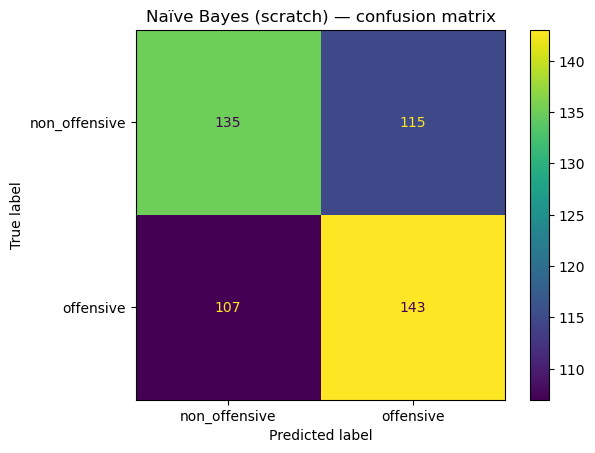

In [25]:
cm = confusion_matrix(y_test, nb_pred, labels=CLASS_ORDER)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
disp.plot(values_format="d")
plt.title("Naïve Bayes (scratch) — confusion matrix")
plt.show()


### 4.5 Inspect mistakes (useful for teaching)

In [27]:
mistakes_df = pd.DataFrame({"text": X_test, "true": y_test, "pred": nb_pred}).reset_index(drop=True)
mistakes_df[mistakes_df["true"] != mistakes_df["pred"]].head(10)


,text,true,pred
1,bravery at its finest fairface_race_white fair...,offensive,non_offensive
3,it is time.. to send these parasites back to t...,offensive,non_offensive
6,life hack #23 how to get stoned with no weed f...,offensive,non_offensive
8,cooooooooooooon!!!! object_dog,offensive,non_offensive
9,when you get to choose your own mental illness,offensive,non_offensive
10,dat ass ahmarbkrich*d fairface_race_white fair...,offensive,non_offensive
16,if this offends you you might be lack toes int...,offensive,non_offensive
19,safe sex isis style object_cow,offensive,non_offensive
20,hurry up barack will be home soon fairface_rac...,offensive,non_offensive
27,thank god my ass needed a break object_dog,offensive,non_offensive


### 4.6 Cost-sensitive decision threshold (posterior odds)

In offensive-language filtering, a **false positive** (non_offensive classified as offensive) is often more costly than a **false negative**.

So instead of predicting offensive whenever it has the larger posterior (MAP), we can require a higher posterior odds:

$
\frac{p(\mathrm{offensive}\mid d)}{p(\mathrm{non\_offensive}\mid d)} > r \quad \Rightarrow \quad \text{predict offensive}.
$

For two classes this is equivalent to:

$
p(\mathrm{offensive}\mid d) > \frac{r}{1+r}.
$

,r,equiv_p_offensive,accuracy,precision(offensive),recall(offensive),f1(offensive)
0,1.0,0.500000,0.556,0.554264,0.572,0.562992
1,1.5,0.600000,0.562,0.604027,0.360,0.451128
2,2.0,0.666667,0.564,0.663265,0.260,0.373563
3,3.0,0.750000,0.542,0.733333,0.132,0.223729
4,5.0,0.833333,0.522,0.789474,0.060,0.111524
5,10.0,0.909091,0.502,0.600000,0.012,0.023529


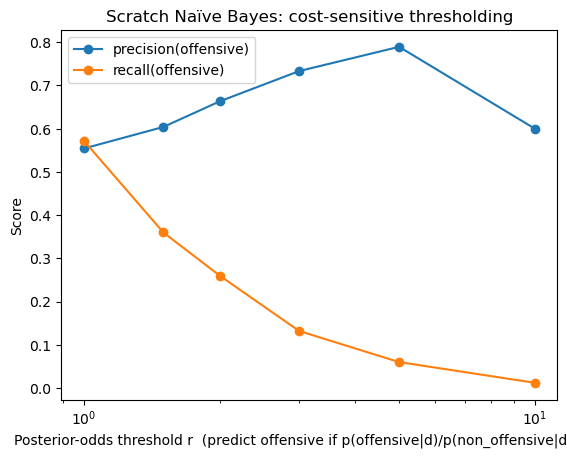

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def predict_positive_by_odds_nb(text: str, r: float = 3.0) -> str:
    # Predict offensive if posterior odds p(offensive|d)/p(non_offensive|d) > r.
    log_positive = nb_scratch.log_posterior_unnorm(text, POSITIVE_LABEL)
    log_negative = nb_scratch.log_posterior_unnorm(text, NEGATIVE_LABEL)
    return POSITIVE_LABEL if (log_positive - log_negative) > np.log(r) else NEGATIVE_LABEL

# Sweep thresholds and show precision/recall trade-off.
thresholds = [1, 1.5, 2, 3, 5, 10]
rows = []
for r in thresholds:
    metrics, _ = eval_classifier(
        lambda x, rr=r: predict_positive_by_odds_nb(x, r=rr),
        X_test.tolist(), y_test.tolist(), positive_label=POSITIVE_LABEL
    )
    rows.append({"r": r, f"equiv_p_{POSITIVE_LABEL}": r/(1+r), **metrics})

df_thr = pd.DataFrame(rows).sort_values("r")
display(df_thr)

precision_col = f"precision({POSITIVE_LABEL})"
recall_col = f"recall({POSITIVE_LABEL})"

plt.figure()
plt.plot(df_thr["r"], df_thr[precision_col], marker="o", label=precision_col)
plt.plot(df_thr["r"], df_thr[recall_col], marker="o", label=recall_col)
plt.xscale("log")
plt.xlabel(f"Posterior-odds threshold r  (predict {POSITIVE_LABEL} if p({POSITIVE_LABEL}|d)/p({NEGATIVE_LABEL}|d) > r)")
plt.ylabel("Score")
plt.title("Scratch Naïve Bayes: cost-sensitive thresholding")
plt.legend()
plt.show()


## 5) Naïve Bayes baselines (scikit-learn)

These are *not* required for the lecture maths, but they help sanity-check the scratch implementation and provide a common reference.

- **BoW (binary) + BernoulliNB**
- **TF–IDF + MultinomialNB**


In [31]:
# BoW (binary presence) + BernoulliNB
sk_bow_nb = BernoulliNB(alpha=1.0)
sk_bow_nb.fit(X_train_bow, y_train)

sk_bow_pred = sk_bow_nb.predict(X_test_bow)
sk_bow_metrics = {
    "accuracy": float(accuracy_score(y_test, sk_bow_pred)),
    **dict(zip(
        [f"precision({POSITIVE_LABEL})", f"recall({POSITIVE_LABEL})", f"f1({POSITIVE_LABEL})"],
        [float(x) for x in precision_recall_fscore_support(y_test, sk_bow_pred, pos_label=POSITIVE_LABEL, average="binary", zero_division=0
        )[:3]]
    ))
}
sk_bow_metrics


{'accuracy': 0.53,
 'precision(offensive)': 0.6027397260273972,
 'recall(offensive)': 0.176,
 'f1(offensive)': 0.2724458204334365}

In [32]:
# TF–IDF + MultinomialNB (very common text baseline)
sk_tfidf_nb = MultinomialNB(alpha=1.0)
sk_tfidf_nb.fit(X_train_tfidf, y_train)

sk_tfidf_pred = sk_tfidf_nb.predict(X_test_tfidf)
sk_tfidf_metrics = {
    "accuracy": float(accuracy_score(y_test, sk_tfidf_pred)),
    **dict(zip(
        [f"precision({POSITIVE_LABEL})", f"recall({POSITIVE_LABEL})", f"f1({POSITIVE_LABEL})"],
        [float(x) for x in precision_recall_fscore_support(y_test, sk_tfidf_pred, pos_label=POSITIVE_LABEL, average="binary", zero_division=0
        )[:3]]
    ))
}
sk_tfidf_metrics


{'accuracy': 0.512,
 'precision(offensive)': 0.6666666666666666,
 'recall(offensive)': 0.048,
 'f1(offensive)': 0.08955223880597014}

## 6) Approach B — Fisher’s Method (from scratch)

### 6.1 Per-feature category probability $p(c\mid f)$

Fisher’s method starts by estimating the probability that a **feature implies a category**, using Bayes’ extended form:
$$
p(c\mid f)=rac{p(f\mid c)\,p(c)}{\sum\limits_{c'\in\mathcal{C}} p(f\mid c')\,p(c')}.
$$

For offensive/non-offensive classification, we often assume equal priors:
$$
p(\mathrm{offensive})=p(\mathrm{non\_offensive})=	frac{1}{2}.
$$

Then, for $c\in\{\mathrm{offensive},\mathrm{non\_offensive}\}$,
$$
p(c\mid f)=rac{p(f\mid c)}{p(f\mid \mathrm{offensive})+p(f\mid \mathrm{non\_offensive})}.
$$

### 6.2 Combine multiple $p(c\mid f_i)$ using Fisher’s method

Given $k$ approximately independent probabilities $\{p(c\mid f_i)\}_{i=1}^{k}$, Fisher’s method forms the statistic
$$
X^2=-2\sum_{i=1}^{k}\ln\!igl(p(c\mid f_i)igr),
$$
which follows a chi-square distribution with $2k$ degrees of freedom under the null:
$$
X^2 \sim \chi^2_{2k}.
$$

The combined p-value is
$$
p_C = 1 - F_{\chi^2}\!\left(X^2; 2kight),
$$
where $F_{\chi^2}(\cdot;\,2k)$ is the CDF of $\chi^2_{2k}$.


In [34]:
class FisherScratch:
    '''
    Fisher classifier (as in the slides / 'Programming Collective Intelligence'):
      1) estimate p(c|f) for each feature
      2) combine per-feature probabilities using Fisher's chi-square method
      3) derive a final score:
            I = (1 + p_offensive - p_non_offensive) / 2   (tends to 1 for offensive, 0 for non_offensive)
    '''
    def __init__(self, assumed: float = 0.5, weight: float = 1.0, prior_equal: bool = True):
        self.assumed = assumed
        self.weight = weight
        self.prior_equal = prior_equal
        self.fc = {}
        self.cc = {}

    @staticmethod
    def features(text: str):
        return set(tokenize(text))

    def incf(self, f, c):
        self.fc.setdefault(f, {})
        self.fc[f][c] = self.fc[f].get(c, 0) + 1

    def incc(self, c):
        self.cc[c] = self.cc.get(c, 0) + 1

    def train(self, texts, labels):
        for text, c in zip(texts, labels):
            feats = self.features(text)
            for f in feats:
                self.incf(f, c)
            self.incc(c)

    def categories(self):
        return list(self.cc.keys())

    def fcount(self, f, c):
        return self.fc.get(f, {}).get(c, 0)

    def catcount(self, c):
        return self.cc.get(c, 0)

    def totalcount(self):
        return sum(self.cc.values())

    def prior(self, c):
        if self.prior_equal:
            return 1.0 / len(self.categories())
        return self.catcount(c) / self.totalcount()

    def fprob(self, f, c):
        if self.catcount(c) == 0:
            return 0.0
        return self.fcount(f, c) / self.catcount(c)

    def cprob_raw(self, f, c):
        denom = 0.0
        for cj in self.categories():
            denom += self.fprob(f, cj) * self.prior(cj)
        if denom == 0:
            return 0.0
        return (self.fprob(f, c) * self.prior(c)) / denom

    def weighted_cprob(self, f, c):
        count = sum(self.fc.get(f, {}).values())
        raw = self.cprob_raw(f, c)
        return (self.weight * self.assumed + count * raw) / (count + self.weight)

    def fisher_prob(self, text, c):
        feats = self.features(text)
        if not feats:
            return 0.0
        ps = [max(self.weighted_cprob(f, c), 1e-12) for f in feats]  # avoid log(0)
        fscore = -2.0 * sum(math.log(p) for p in ps)
        return float(chi2.sf(fscore, df=2 * len(ps)))

    def score_I(self, text):
        p_positive = self.fisher_prob(text, POSITIVE_LABEL)
        p_negative = self.fisher_prob(text, NEGATIVE_LABEL)
        return (1.0 + p_positive - p_negative) / 2.0

    def predict(self, text, threshold=0.5):
        return POSITIVE_LABEL if self.score_I(text) >= threshold else NEGATIVE_LABEL

# Train
fish_scratch = FisherScratch(assumed=0.5, weight=1.0, prior_equal=True)
fish_scratch.train(X_train.tolist(), y_train.tolist())

msg = X_test.iloc[0]
print("Message:", msg)
print(f"p_{POSITIVE_LABEL}:", fish_scratch.fisher_prob(msg, POSITIVE_LABEL))
print(f"p_{NEGATIVE_LABEL}:", fish_scratch.fisher_prob(msg, NEGATIVE_LABEL))
print(f"I ({POSITIVE_LABEL} score):", fish_scratch.score_I(msg))


Message: white people is this a shooting range fairface_race_east_asian fairface_gender_female fairface_age_20_29 fairface_race_white fairface_gender_female fairface_age_20_29 fairface_race_white fairface_gender_male fairface_age_30_39 fairface_race_east_asian fairface_gender_male fairface_age_20_29 fairface_race_white fairface_gender_female fairface_age_20_29 fairface_race_white fairface_gender_male fairface_age_20_29 object_person object_person object_person object_person object_person
p_offensive: 0.9339575170613985
p_non_offensive: 0.7839892069853878
I (offensive score): 0.5749841550380054


### 6.3 Evaluate Fisher’s method (scratch)

In [36]:
fish_metrics, fish_pred = eval_classifier(
    fish_scratch.predict, X_test.tolist(), y_test.tolist(), positive_label=POSITIVE_LABEL
)
fish_metrics


{'accuracy': 0.538,
 'precision(offensive)': 0.5281899109792285,
 'recall(offensive)': 0.712,
 'f1(offensive)': 0.606473594548552}

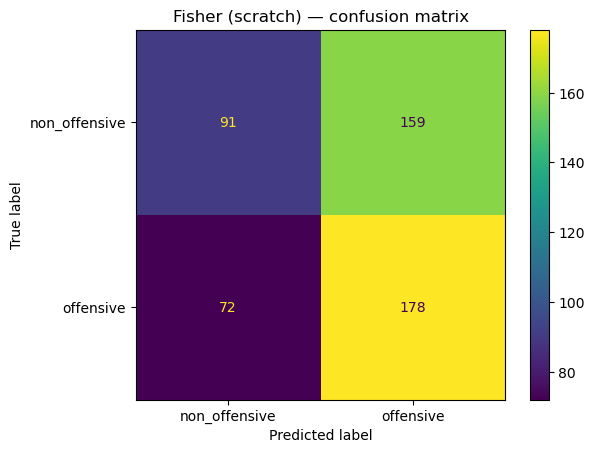

In [37]:
cm = confusion_matrix(y_test, fish_pred, labels=CLASS_ORDER)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
disp.plot(values_format="d")
plt.title("Fisher (scratch) — confusion matrix")
plt.show()


### 6.4 Visualise Fisher score distributions

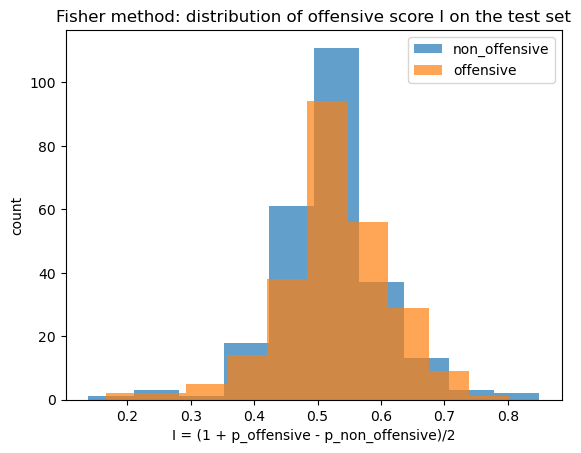

In [39]:
scores = np.array([fish_scratch.score_I(t) for t in X_test.tolist()])
is_positive = (y_test.values == POSITIVE_LABEL)

plt.figure()
plt.hist(scores[~is_positive], bins=10, alpha=0.7, label=NEGATIVE_LABEL)
plt.hist(scores[is_positive],  bins=10, alpha=0.7, label=POSITIVE_LABEL)
plt.xlabel(f"I = (1 + p_{POSITIVE_LABEL} - p_{NEGATIVE_LABEL})/2")
plt.ylabel("count")
plt.title(f"Fisher method: distribution of {POSITIVE_LABEL} score I on the test set")
plt.legend()
plt.show()


## 7) Comparison (visual + quantitative)

In [41]:
results = pd.DataFrame({
    "Naïve Bayes (scratch)": nb_metrics,
    "BernoulliNB (BoW)": sk_bow_metrics,
    "MultinomialNB (TF–IDF)": sk_tfidf_metrics,
    "Fisher (scratch)": fish_metrics,
}).T

results


,accuracy,precision(offensive),recall(offensive),f1(offensive)
Naïve Bayes (scratch),0.556,0.554264,0.572,0.562992
BernoulliNB (BoW),0.530,0.602740,0.176,0.272446
MultinomialNB (TF–IDF),0.512,0.666667,0.048,0.089552
Fisher (scratch),0.538,0.528190,0.712,0.606474


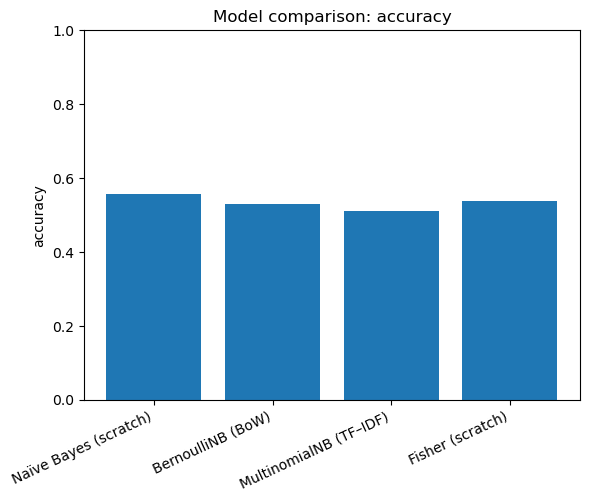

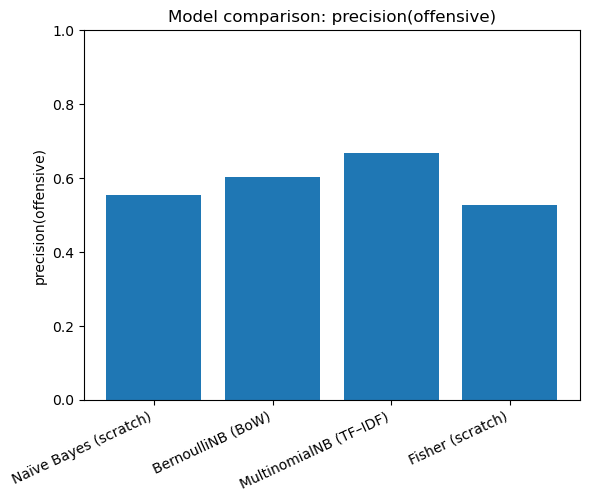

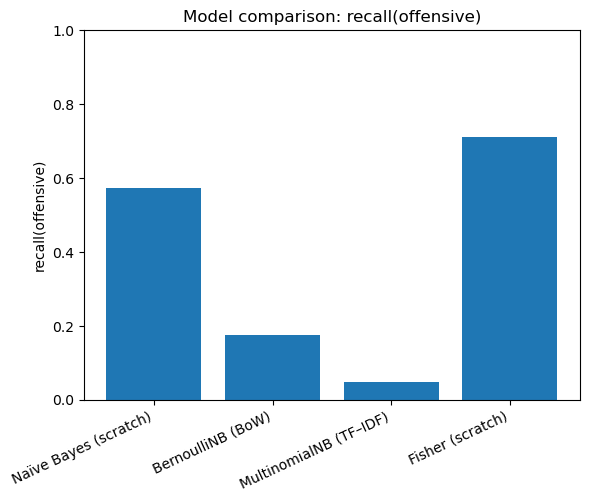

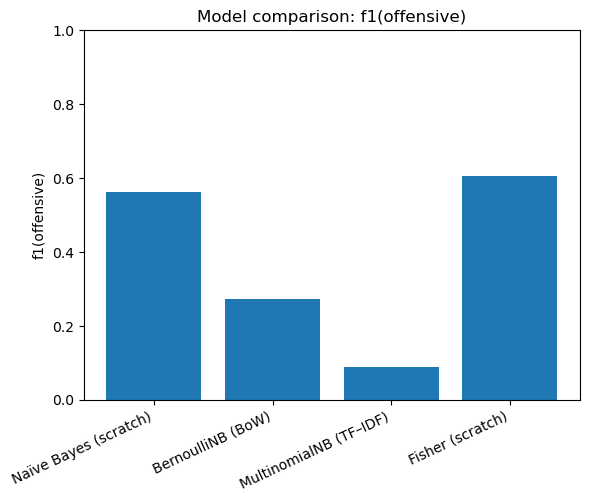

In [42]:
for metric in ["accuracy", f"precision({POSITIVE_LABEL})", f"recall({POSITIVE_LABEL})", f"f1({POSITIVE_LABEL})"]:
    plt.figure()
    plt.bar(results.index, results[metric].values)
    plt.xticks(rotation=25, ha="right")
    plt.ylabel(metric)
    plt.title(f"Model comparison: {metric}")
    plt.ylim(0, 1)
    plt.show()


## 8) Optional feature engineering extension: n-grams (bigrams)

Bag of Words loses word order. In phase 2, n-grams can capture short text phrases while still keeping FairFace/object label tokens as part of the same tokenizer vector.


In [44]:
ngram_vec = CountVectorizer(
    tokenizer=tokenize,
    lowercase=False,
    binary=True,
    ngram_range=(1, 2)  # unigrams + bigrams
)

X_train_ng = ngram_vec.fit_transform(X_train)
X_test_ng  = ngram_vec.transform(X_test)

ng_nb = BernoulliNB(alpha=1.0)
ng_nb.fit(X_train_ng, y_train)
ng_pred = ng_nb.predict(X_test_ng)

ng_metrics = {
    "accuracy": float(accuracy_score(y_test, ng_pred)),
    **dict(zip(
        [f"precision({POSITIVE_LABEL})", f"recall({POSITIVE_LABEL})", f"f1({POSITIVE_LABEL})"],
        [float(x) for x in precision_recall_fscore_support(y_test, ng_pred, pos_label=POSITIVE_LABEL, average="binary", zero_division=0
        )[:3]]
    ))
}
ng_metrics


E:\anaconda\Lib\site-packages\sklearn\feature_extraction\text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


{'accuracy': 0.508,
 'precision(offensive)': 0.75,
 'recall(offensive)': 0.024,
 'f1(offensive)': 0.046511627906976744}

## 9) Quick interactive test

Edit `my_message` and re-run the cell to compare models.


In [46]:
def pretty_proba(d: dict):
    return ", ".join([f"{k}={v:.3f}" for k, v in d.items()])

def build_phase2_input(text, fairface_labels="", object_labels=""):
    """Use this helper for manual tests with optional image-derived labels."""
    return f"{text} {fairface_labels} {object_labels}".strip()

my_message = build_phase2_input(
    "I love everything and everybody.",
    fairface_labels="fairface_gender_female fairface_age_20_29",
    object_labels="object_person"
)

print("Model input:", my_message)
print("Naïve Bayes (scratch):", nb_scratch.predict(my_message), pretty_proba(nb_scratch.predict_proba(my_message)))
print("Fisher (scratch):    ", fish_scratch.predict(my_message), f"I={fish_scratch.score_I(my_message):.3f}")

bow_p = bow_vec.transform([my_message])
print("BernoulliNB (BoW):   ", sk_bow_nb.predict(bow_p)[0],
      pretty_proba(dict(zip(sk_bow_nb.classes_, sk_bow_nb.predict_proba(bow_p)[0]))))

tfidf_p = tfidf_vec.transform([my_message])
print("TF–IDF + MultinomialNB:", sk_tfidf_nb.predict(tfidf_p)[0],
      pretty_proba(dict(zip(sk_tfidf_nb.classes_, sk_tfidf_nb.predict_proba(tfidf_p)[0]))))


Model input: I love everything and everybody. fairface_gender_female fairface_age_20_29 object_person
Naïve Bayes (scratch): non_offensive non_offensive=0.614, offensive=0.386
Fisher (scratch):     non_offensive I=0.498
BernoulliNB (BoW):    non_offensive non_offensive=0.968, offensive=0.032
TF–IDF + MultinomialNB: non_offensive non_offensive=0.804, offensive=0.196


## 10) Summary (phase 2 takeaways)

- **Document filtering** is still a supervised binary classification problem: offensive vs non-offensive.

- **Phase 2 feature input** uses a tokenizer vector over:
  - original text tokens
  - FairFace labels from `human_results.csv`
  - object labels from `object_detections.csv`

- **Feature engineering** is critical:
  - Bag of Words / tokenizer vectors are simple and effective
  - TF–IDF reweights distinctive tokens
  - n-grams can capture short phrases

- **Naïve Bayes** estimates $p(f\mid c)$ and combines evidence using the independence assumption.

- **Fisher’s method** estimates $p(c\mid f)$ per token and combines evidence via Fisher’s $\chi^2$ method.

> **Takeaway:** the model can now learn from both text and image-derived labels in a single vectorized feature space.
